In [1]:
import numpy as np

In [ ]:
class Conv2d:
    def __init__(self, out_channels, in_channels=1, kernelh=3, kernelw=3, padding = False):
        self.out_channels = out_channels
        self.in_channels = in_channels
        self.kernelh = kernelh    
        self.kernelw = kernelw
        self.padding = padding 

        # n_in = número total de valores por kernel
        n_in = in_channels * kernelh * kernelw
        
        # Inicialización He (ideal para ReLU)
        self.filters = np.random.randn(out_channels, in_channels, kernelh, kernelw) \
                       * np.sqrt(2.0 / n_in)
        
    def regiones(self,imagen):
        inc,h,w = imagen.shape
        kernelh = self.kernelh
        kernelw = self.kernelw

        for i in range(h-(kernelh-1)):
            for j in range(w-(kernelw-1)):
                subregion = imagen[:,i:(i+kernelh),j:(j+kernelw)]
                yield subregion,i,j 

    def forward(self,input):
        if self.padding:
            pad_h = self.kernelh // 2
            pad_w = self.kernelw // 2

            input = np.pad(
            input,
            pad_width=((0,0), (pad_h, pad_h), (pad_w, pad_w)),  # canales, alto, ancho
            mode="constant",
            constant_values=0)
        in_c, h, w = input.shape
        kernelh = self.kernelh
        kernelw = self.kernelw
        output = np.zeros((h - kernelh + 1, w - kernelw + 1,self.out_channels))

        for subregion,i,j in self.regiones(input):
            output[i, j] = np.sum(subregion * self.filters, axis=(1, 2, 3))
        return output

class Pooling():
    def __init__(self, tamaño_pool):
        self.tamaño_pool = tamaño_pool 
    
    def iterate_regions(self, image):
        h, w, out_channel = image.shape
        h_pool = h // self.tamaño_pool
        w_pool = w // self.tamaño_pool

        for i in range(h_pool):
            for j in range(w_pool):
                im_region = image[(i * self.tamaño_pool):(i * self.tamaño_pool + self.tamaño_pool), (j * self.tamaño_pool):(j * self.tamaño_pool + self.tamaño_pool),:]
                yield im_region, i, j
    
    def forward(self, input):

        h, w, out_channel = input.shape
        output = np.zeros((h // self.tamaño_pool, w // self.tamaño_pool, out_channel))

        for im_region, i, j in self.iterate_regions(input):
            output[i, j] = np.max(im_region, axis=(0, 1))

        return output
    

class Softmax:
  def __init__(self, input_len, nodes):
    self.weights = np.random.randn(input_len, nodes) / input_len
    self.biases = np.zeros(nodes)

  def forward(self, input):
    input = input.flatten()
    input_len, nodes = self.weights.shape

    totals = np.dot(input, self.weights) + self.biases
    exp = np.exp(totals)
    return exp / np.sum(exp, axis=0)



In [2]:
from tensorflow.keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [ ]:
# Convertir a float (tu conv lo necesita)
train_images = train_images.astype(np.float32)

# Seleccionar la imagen 0
img = train_images[0]          # (28, 28)
img = img.reshape(1, 28, 28)   # (1, 28, 28)

# Crear tu conv
conv = Conv2d(out_channels=8, in_channels=1, kernelh=3, kernelw=3)

# Forward
output = conv.forward(img)
print(output.shape)

pool = Pooling(2)

output = conv.forward(img)
output = pool.forward(output)
print(output.shape) # (13, 13, 8)

softmax = Softmax(13 * 13 * 8, 10) # 13x13x8 -> 10

def forward(image, label):
    # Normalizar
    image = (image / 255.0) - 0.5

    # Añadir canal
    image = image.reshape(1, 28, 28)

    # Forward por las capas
    out = conv.forward(image)      # → (28, 28, out_channels)
    out = pool.forward(out)        # → (14, 14, out_channels)
    out = softmax.forward(out)     # → (10,)

    # Cross entropy
    loss = -np.log(out[label])

    # Accuracy
    acc = 1 if np.argmax(out) == label else 0

    return out, loss, acc

print("Evaluando tu CNN...")

loss = 0
num_correct = 0

for i, (im, label) in enumerate(zip(test_images, test_labels)):
    _, l, acc = forward(im, label)
    loss += l
    num_correct += acc

    if i % 100 == 99:
        print(
            f"[Step {i+1}] Past 100 steps: "
            f"Average Loss {loss/100:.3f} | Accuracy: {num_correct}%"
        )
        loss = 0
        num_correct = 0

(26, 26, 8)
(13, 13, 8)
Evaluando tu CNN...
[Step 100] Past 100 steps: Average Loss 2.301 | Accuracy: 14%
[Step 200] Past 100 steps: Average Loss 2.299 | Accuracy: 18%
[Step 300] Past 100 steps: Average Loss 2.304 | Accuracy: 8%
[Step 400] Past 100 steps: Average Loss 2.303 | Accuracy: 10%
[Step 500] Past 100 steps: Average Loss 2.304 | Accuracy: 7%
[Step 600] Past 100 steps: Average Loss 2.304 | Accuracy: 9%
[Step 700] Past 100 steps: Average Loss 2.303 | Accuracy: 12%
[Step 800] Past 100 steps: Average Loss 2.304 | Accuracy: 8%
[Step 900] Past 100 steps: Average Loss 2.307 | Accuracy: 9%
[Step 1000] Past 100 steps: Average Loss 2.305 | Accuracy: 18%
[Step 1100] Past 100 steps: Average Loss 2.304 | Accuracy: 9%
[Step 1200] Past 100 steps: Average Loss 2.300 | Accuracy: 17%
[Step 1300] Past 100 steps: Average Loss 2.304 | Accuracy: 12%
[Step 1400] Past 100 steps: Average Loss 2.303 | Accuracy: 11%
[Step 1500] Past 100 steps: Average Loss 2.303 | Accuracy: 12%
[Step 1600] Past 100 steps

In [6]:
class Conv2d:
    def __init__(self, out_channels, in_channels=1, kernelh=3, kernelw=3, padding = False):
        self.out_channels = out_channels
        self.in_channels = in_channels
        self.kernelh = kernelh
        self.kernelw = kernelw
        self.padding = padding 

        # n_in = número total de valores por kernel
        n_in = in_channels * kernelh * kernelw
        
        # Inicialización He (ideal para ReLU)
        self.filters = np.random.randn(out_channels, in_channels, kernelh, kernelw) \
                       * np.sqrt(2.0 / n_in)
        
    def regiones(self,imagen):
        inc,h,w = imagen.shape
        kernelh = self.kernelh
        kernelw = self.kernelw

        for i in range(h-(kernelh-1)):
            for j in range(w-(kernelw-1)):
                subregion = imagen[:,i:(i+kernelh),j:(j+kernelw)]
                yield subregion,i,j 

    def forward(self, input):

        # Guardamos el input PARA BACKPROP
        self.last_input = input.copy()

        if self.padding:
            pad_h = self.kernelh // 2
            pad_w = self.kernelw // 2

            input = np.pad(
                input,
                pad_width=((0,0), (pad_h, pad_h), (pad_w, pad_w)),
                mode="constant",
                constant_values=0
            )

            # Debemos guardar el input con padding
            self.last_input = input.copy()

        in_c, h, w = input.shape
        kh, kw = self.kernelh, self.kernelw

        # Salida
        output = np.zeros((h - kh + 1, w - kw + 1, self.out_channels))

        # Convolución
        for subregion, i, j in self.regiones(input):
            output[i, j] = np.sum(subregion * self.filters, axis=(1, 2, 3))

        return output

        
    def backprop(self, d_L_d_out, learn_rate):
        # d_L_d_out tiene shape: (out_h, out_w, out_channels)

        d_L_d_filters = np.zeros(self.filters.shape)

        # Para cada posición donde aplicamos el kernel
        for subregion, i, j in self.regiones(self.last_input):
            for oc in range(self.out_channels):
                d_L_d_filters[oc] += d_L_d_out[i,j,oc] * subregion

        # Actualización
        self.filters -= learn_rate * d_L_d_filters

        return None


class Pooling:
    def __init__(self, tamaño_pool):
        self.tamaño_pool = tamaño_pool
    
    def iterate_regions(self, image):
        h, w, c = image.shape
        pool = self.tamaño_pool

        out_h = h // pool
        out_w = w // pool

        for i in range(out_h):
            for j in range(out_w):
                region = image[
                    i * pool : i * pool + pool,
                    j * pool : j * pool + pool,
                    :
                ]
                yield region, i, j
    
    def forward(self, input):
        self.last_input = input     

        h, w, c = input.shape
        pool = self.tamaño_pool

        output = np.zeros((h // pool, w // pool, c))

        for region, i, j in self.iterate_regions(input):
            output[i, j] = np.max(region, axis=(0, 1))

        return output
    
    def backprop(self, d_L_d_out):

        pool = self.tamaño_pool
        input = self.last_input

        h, w, c = input.shape
        d_L_d_input = np.zeros_like(input)

        for region, i, j in self.iterate_regions(input):

            max_vals = np.max(region, axis=(0, 1))

            for i2 in range(pool):
                for j2 in range(pool):
                    for c2 in range(c):
                        if region[i2, j2, c2] == max_vals[c2]:
                            d_L_d_input[i * pool + i2,
                                        j * pool + j2,
                                        c2] = d_L_d_out[i, j, c2]

        return d_L_d_input

    

class Softmax:
  def __init__(self, input_len, nodes):
    self.weights = np.random.randn(input_len, nodes) / input_len
    self.biases = np.zeros(nodes)

  def forward(self, input):
        # Guardar forma original (h, w, channels)
        self.last_input_shape = input.shape

        # Aplanar
        input = input.flatten()
        self.last_input = input

        # Logits
        totals = np.dot(input, self.weights) + self.biases
        self.last_totals = totals

        # Softmax estable
        exp = np.exp(totals - np.max(totals))
        return exp / np.sum(exp)

  

  def backprop(self, d_L_d_out, learn_rate):

    # d_L_d_out es un gradiente tamaño (clases,)
    # Solo una entrada es !=0 en cross entropy con softmax

    for i, grad in enumerate(d_L_d_out):
        if grad == 0:
            continue

        # Softmax estable (ya calculado)
        t_exp = np.exp(self.last_totals - np.max(self.last_totals))
        S = np.sum(t_exp)

        # Derivada de softmax wrt totals
        d_out_d_t = -t_exp * t_exp[i] / (S**2)
        d_out_d_t[i] = t_exp[i] * (S - t_exp[i]) / (S**2)

        # Gradientes wrt pesos y bias
        d_t_d_w = self.last_input           # shape (features,)
        d_t_d_input = self.weights          # shape (features, classes)

        d_L_d_t = grad * d_out_d_t          # (classes,)

        # Gradiente wrt pesos
        d_L_d_w = d_t_d_w[:, np.newaxis] @ d_L_d_t[np.newaxis, :]
        d_L_d_b = d_L_d_t
        d_L_d_inputs = d_t_d_input @ d_L_d_t

        # Actualización
        self.weights -= learn_rate * d_L_d_w
        self.biases  -= learn_rate * d_L_d_b

    return d_L_d_inputs.reshape(self.last_input_shape)

In [13]:
# Convertir a float (tu conv lo necesita)
train_images = train_images.astype(np.float32)

# Seleccionar la imagen 0
img = train_images[0]          # (28, 28)
img = img.reshape(1, 28, 28)   # (1, 28, 28)

# Crear tu conv
conv = Conv2d(out_channels=8, in_channels=1, kernelh=3, kernelw=3)

# Forward
output = conv.forward(img)
print(output.shape)

pool = Pooling(2)

output = conv.forward(img)
output = pool.forward(output)
print(output.shape) # (13, 13, 8)

softmax = Softmax(13 * 13 * 8, 10) # 13x13x8 -> 10

def forward(image, label):
    """
    Realiza el forward completo de tu CNN personalizada
    y devuelve (predicción, pérdida, accuracy).
    """

    # Normalizar imagen y añadir canal
    x = (image / 255.0) - 0.5
    x = x.reshape(1, 28, 28)   # (canal, alto, ancho)

    # Forward por cada capa
    out = conv.forward(x)
    out = pool.forward(out)
    out = softmax.forward(out)

    # Cross entropy estable
    loss = -np.log(out[label] + 1e-7)

    # Accuracy (predicción correcta = 1)
    acc = 1 if np.argmax(out) == label else 0

    return out, loss, acc

def train(image, label, lr=0.005):
    """
    Realiza un paso completo de entrenamiento:
    forward + backward + update.
    Devuelve (pérdida, accuracy).
    """

    # Forward
    out, loss, acc = forward(image, label)

    # Gradiente inicial (derivada de la cross-entropy)
    gradient = np.zeros(10)
    gradient[label] = -1 / (out[label] + 1e-7)

    # Backprop por orden inverso
    gradient = softmax.backprop(gradient, lr)
    gradient = pool.backprop(gradient)
    gradient = conv.backprop(gradient, lr)

    return loss, acc

# HYPERPARÁMETROS PARA ACORTAR
num_epochs = 1              # antes 3
max_steps_per_epoch = 3000  # como mucho 1000 imágenes por epoch

# Train the CNN for num_epochs epochs
for epoch in range(num_epochs):
    print('--- Epoch %d ---' % (epoch + 1))

    # Shuffle the training data
    permutation = np.random.permutation(len(train_images))
    train_images = train_images[permutation]
    train_labels = train_labels[permutation]

    loss = 0
    num_correct = 0

    for i, (im, label) in enumerate(zip(train_images, train_labels)):
        # PARAR PRONTO LA ÉPOCA
        if i >= max_steps_per_epoch:
            break

        if i > 0 and i % 100 == 99:
            print(
                '[Step %d] Past 100 steps: Average Loss %.3f | Accuracy: %d%%' %
                (i + 1, loss / 100, num_correct)
            )
            loss = 0
            num_correct = 0

        l, acc = train(im, label)
        loss += l
        num_correct += acc

print('\n--- Testing the CNN ---')
loss = 0
num_correct = 0

max_test_samples = 2000   # en vez de todas

for i, (im, label) in enumerate(zip(test_images, test_labels)):
    if i >= max_test_samples:
        break

    _, l, acc = forward(im, label)
    loss += l
    num_correct += acc

num_tests = min(len(test_images), max_test_samples)
print('Test Loss:', loss / num_tests)
print('Test Accuracy:', num_correct / num_tests)

(26, 26, 8)
(13, 13, 8)
--- Epoch 1 ---
[Step 100] Past 100 steps: Average Loss 2.133 | Accuracy: 28%
[Step 200] Past 100 steps: Average Loss 1.257 | Accuracy: 67%
[Step 300] Past 100 steps: Average Loss 0.966 | Accuracy: 69%
[Step 400] Past 100 steps: Average Loss 0.616 | Accuracy: 83%
[Step 500] Past 100 steps: Average Loss 0.623 | Accuracy: 76%
[Step 600] Past 100 steps: Average Loss 0.585 | Accuracy: 80%
[Step 700] Past 100 steps: Average Loss 0.665 | Accuracy: 73%
[Step 800] Past 100 steps: Average Loss 0.577 | Accuracy: 86%
[Step 900] Past 100 steps: Average Loss 0.421 | Accuracy: 86%
[Step 1000] Past 100 steps: Average Loss 0.507 | Accuracy: 84%
[Step 1100] Past 100 steps: Average Loss 0.511 | Accuracy: 80%
[Step 1200] Past 100 steps: Average Loss 0.392 | Accuracy: 90%
[Step 1300] Past 100 steps: Average Loss 0.448 | Accuracy: 86%
[Step 1400] Past 100 steps: Average Loss 0.325 | Accuracy: 93%
[Step 1500] Past 100 steps: Average Loss 0.608 | Accuracy: 81%
[Step 1600] Past 100 ste


🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬
DEMO PARA VIDEO
🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬🎬

1️⃣ Clasificando números específicos...


🔍 Clasificando un '0'...


C:\Users\usuario\AppData\Local\Temp\ipykernel_24032\1978381291.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
c:\Users\usuario\Desktop\Estudiar IA\ia\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\usuario\Desktop\Estudiar IA\ia\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


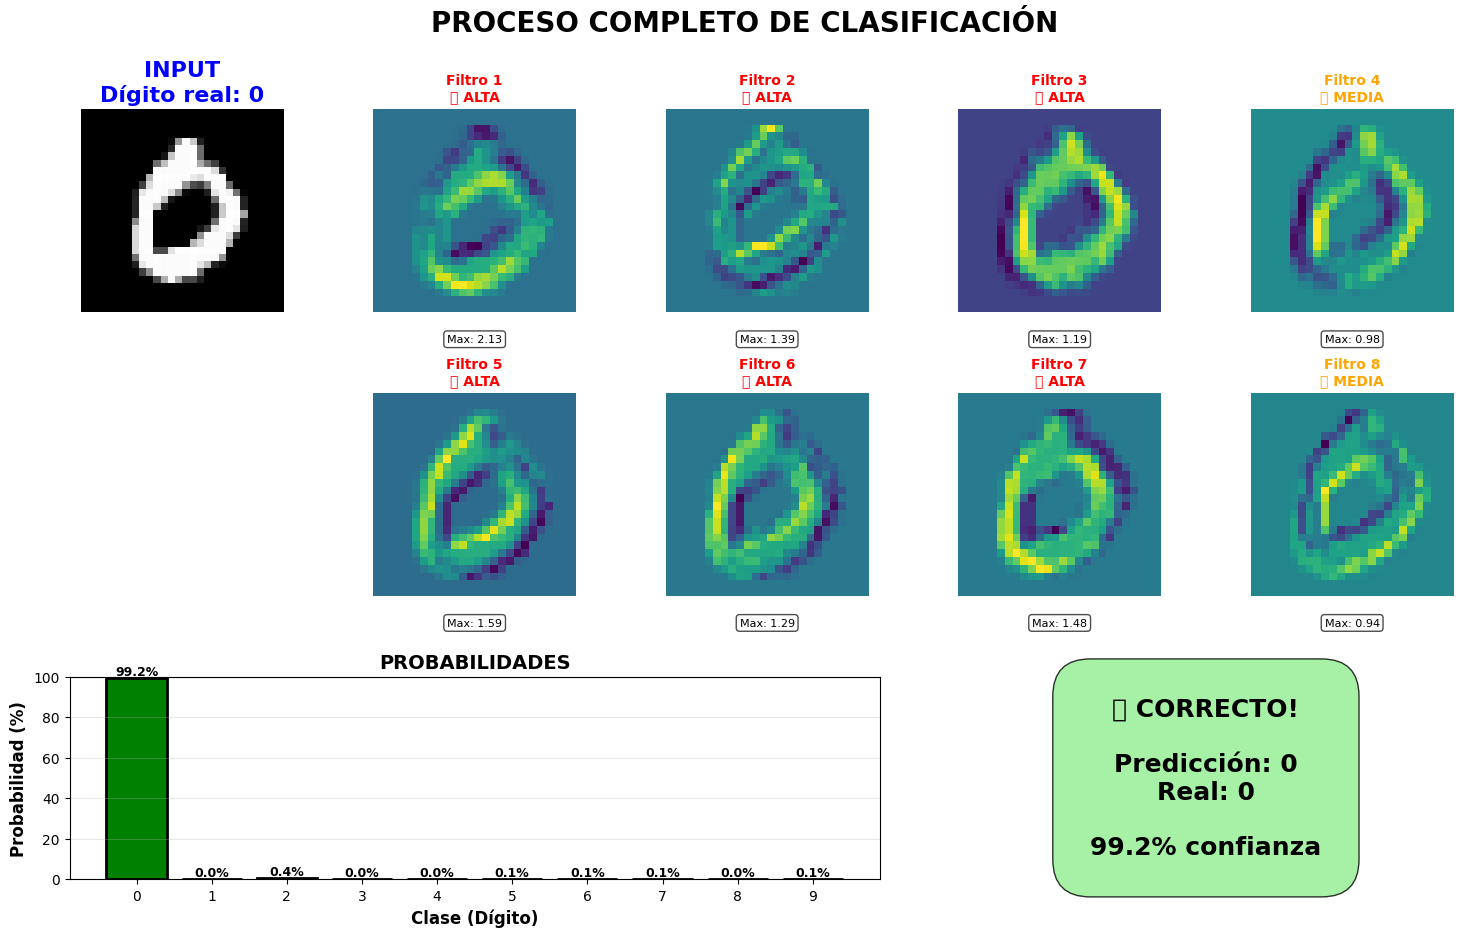


Predicción: 0 | Real: 0 | Confianza: 99.2%


🔍 Clasificando un '3'...


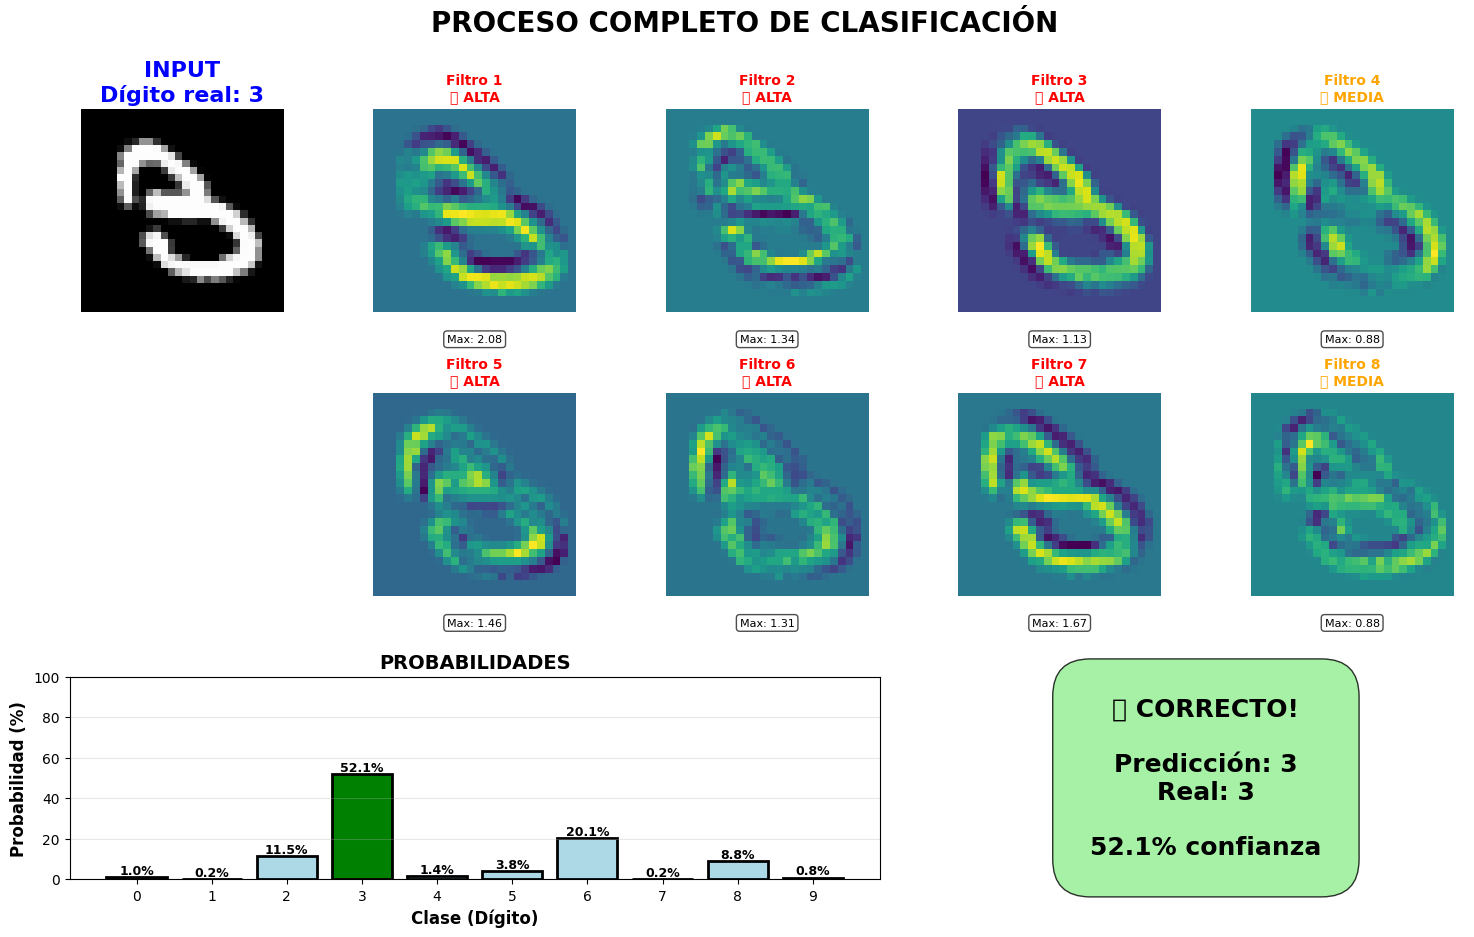


Predicción: 3 | Real: 3 | Confianza: 52.1%


🔍 Clasificando un '7'...


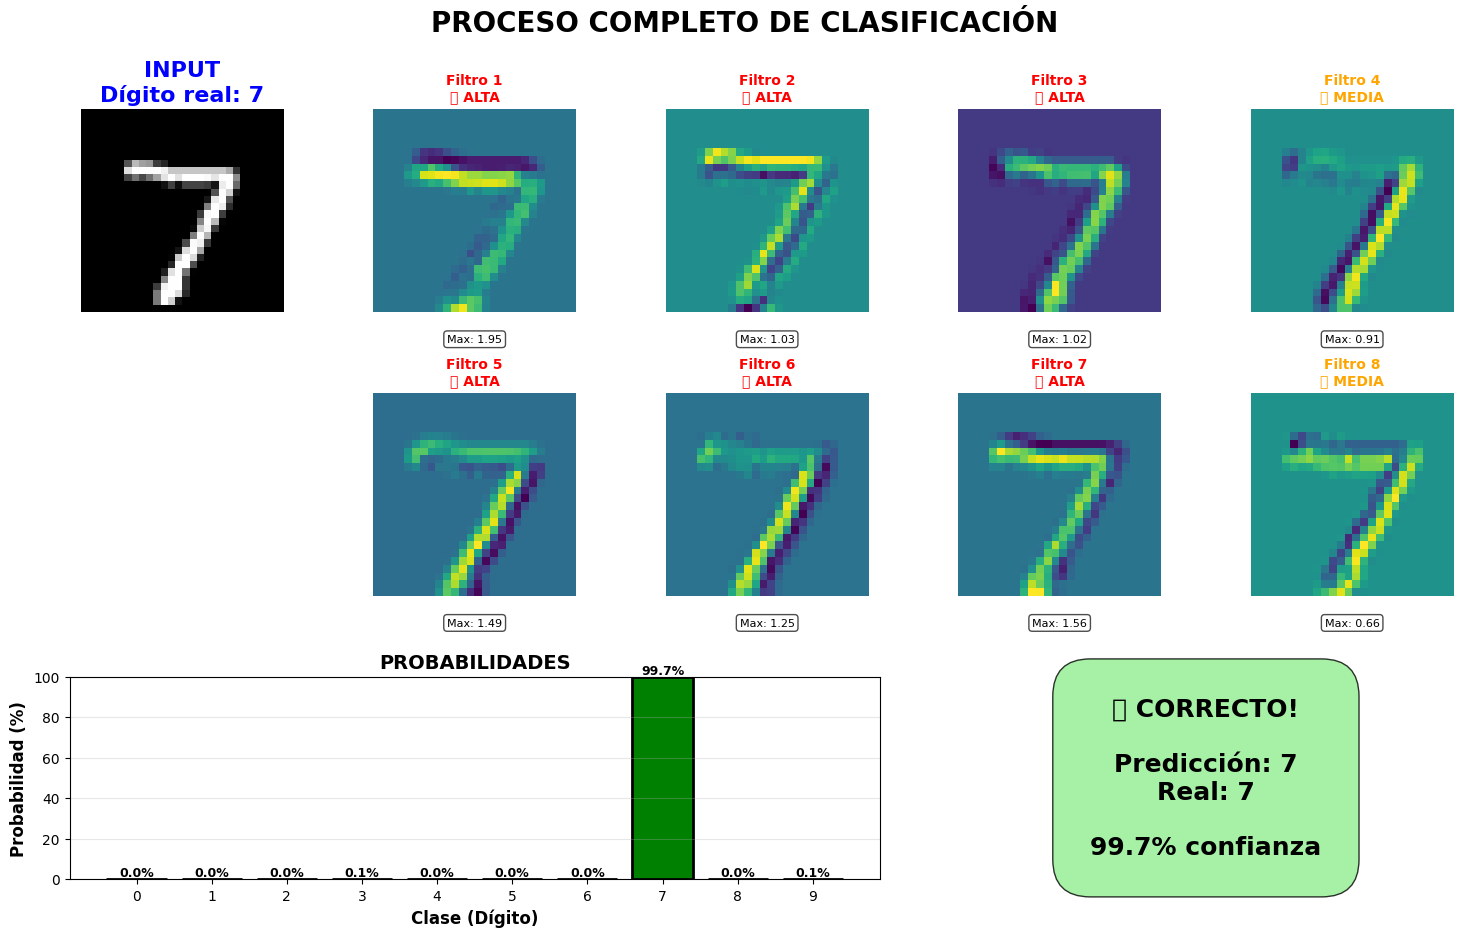


Predicción: 7 | Real: 7 | Confianza: 99.7%


🔥 ANÁLISIS DETALLADO DE CARACTERÍSTICAS...



C:\Users\usuario\AppData\Local\Temp\ipykernel_24032\1978381291.py:214: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
c:\Users\usuario\Desktop\Estudiar IA\ia\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


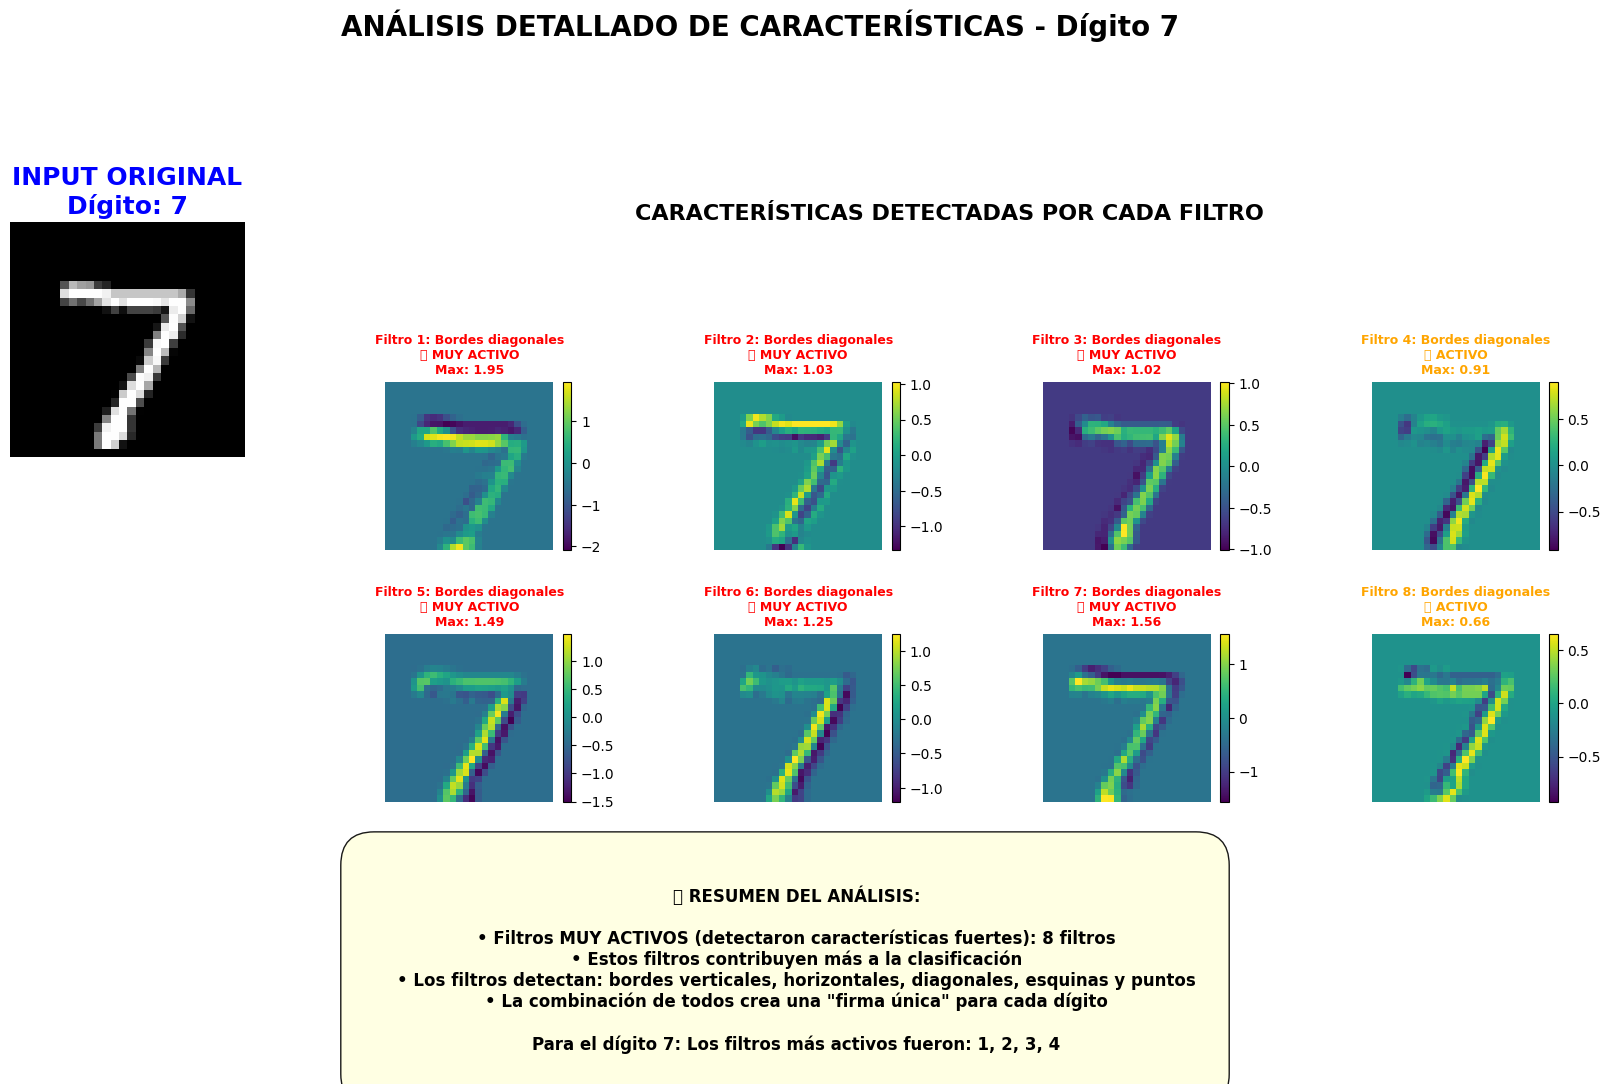


ANÁLISIS DE ACTIVACIONES PARA EL DÍGITO 7

🔥 Filtro 1: Activación máxima = 1.949 | Media = -0.417
🔥 Filtro 2: Activación máxima = 1.034 | Media = -0.135
🔥 Filtro 3: Activación máxima = 1.022 | Media = -0.518
🟡 Filtro 4: Activación máxima = 0.906 | Media = -0.006
🔥 Filtro 5: Activación máxima = 1.492 | Media = -0.331
🔥 Filtro 6: Activación máxima = 1.248 | Media = -0.212
🔥 Filtro 7: Activación máxima = 1.564 | Media = -0.277
🟡 Filtro 8: Activación máxima = 0.659 | Media = -0.091




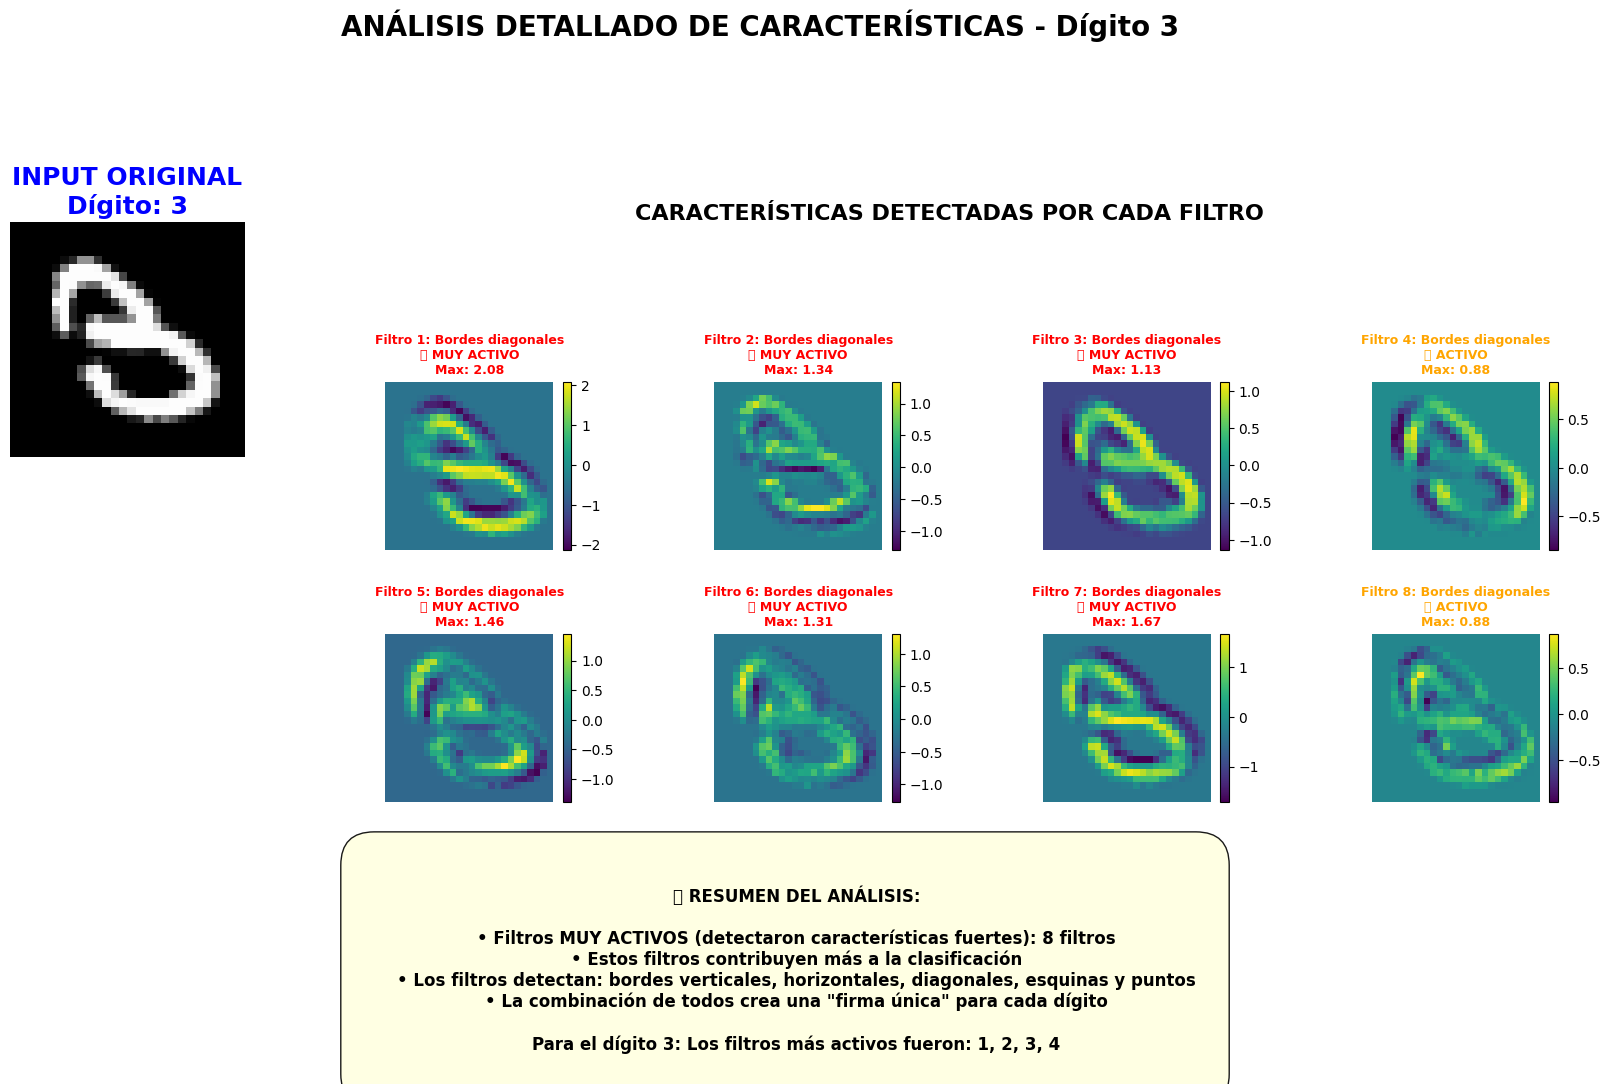


ANÁLISIS DE ACTIVACIONES PARA EL DÍGITO 3

🔥 Filtro 1: Activación máxima = 2.080 | Media = -0.307
🔥 Filtro 2: Activación máxima = 1.344 | Media = -0.100
🔥 Filtro 3: Activación máxima = 1.126 | Media = -0.388
🟡 Filtro 4: Activación máxima = 0.881 | Media = -0.005
🔥 Filtro 5: Activación máxima = 1.456 | Media = -0.249
🔥 Filtro 6: Activación máxima = 1.310 | Media = -0.159
🔥 Filtro 7: Activación máxima = 1.673 | Media = -0.207
🟡 Filtro 8: Activación máxima = 0.880 | Media = -0.068



2️⃣ Clasificando múltiples dígitos...



C:\Users\usuario\AppData\Local\Temp\ipykernel_24032\1978381291.py:284: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\usuario\AppData\Local\Temp\ipykernel_24032\1978381291.py:284: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


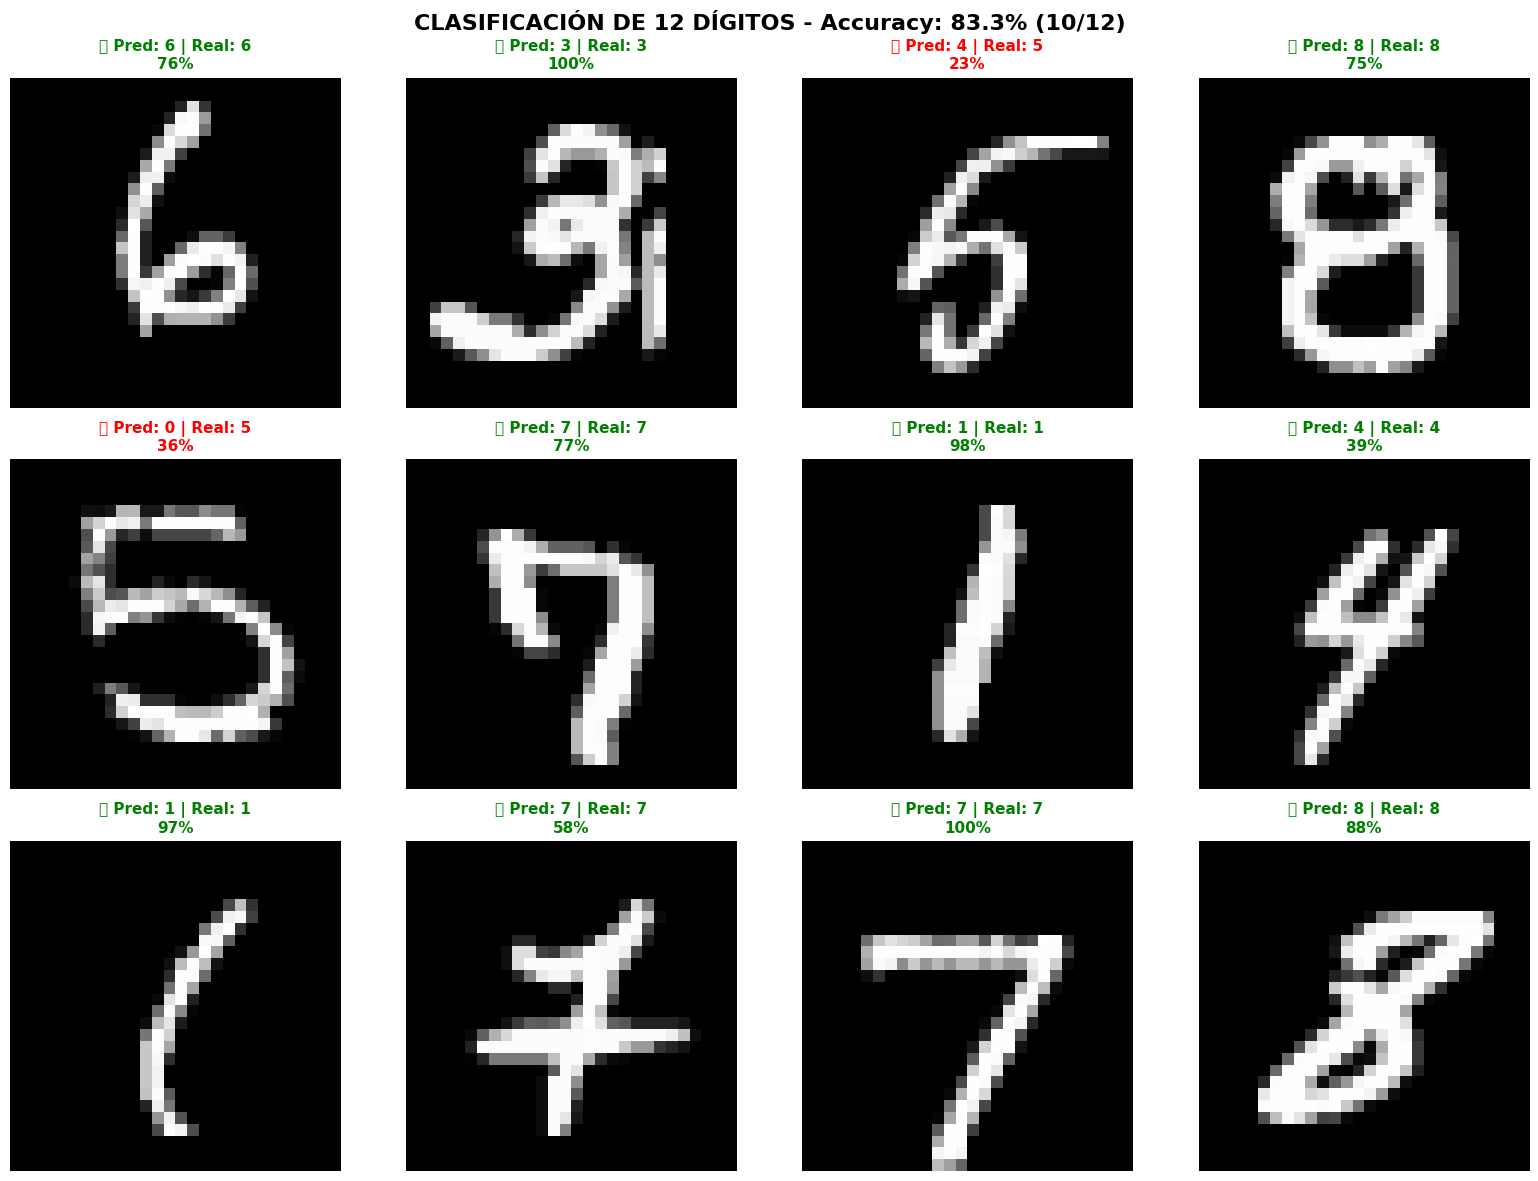


Accuracy: 83.3% (10/12 correctos)


3️⃣ Visualizando filtros...



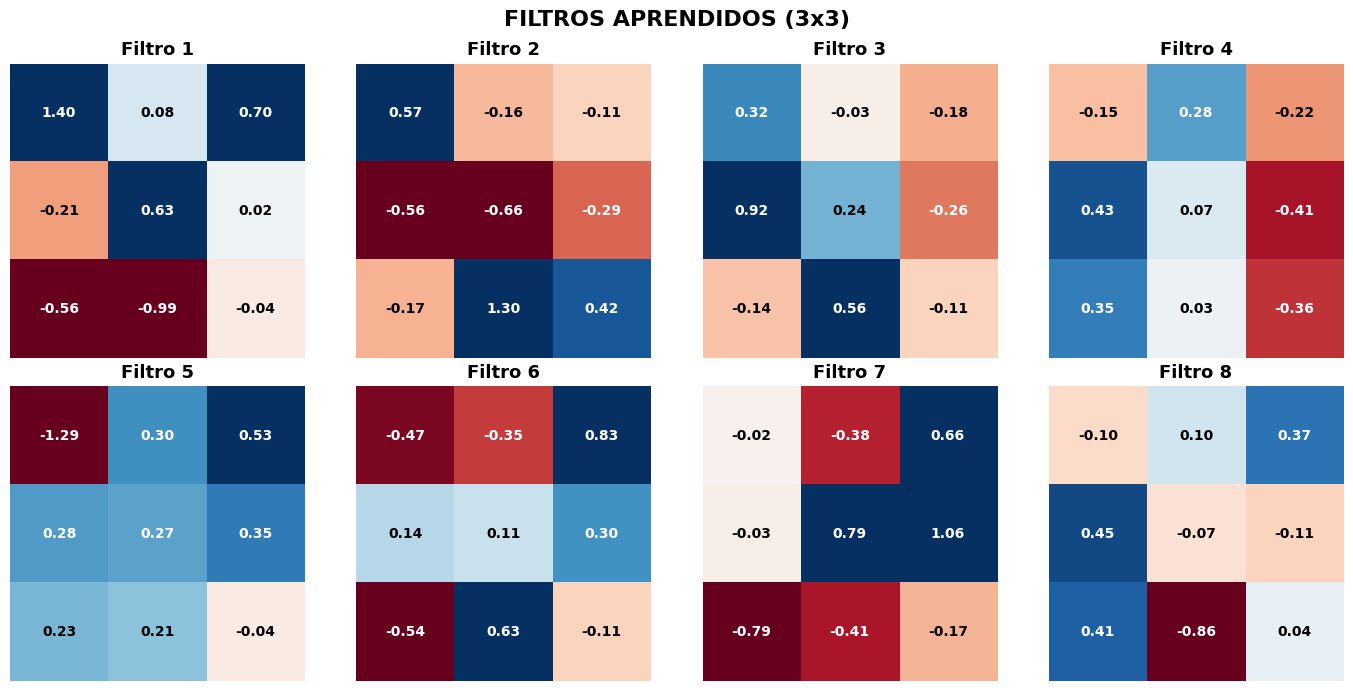


✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅
DEMO COMPLETADA
✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅✅



In [15]:
# ============================================================================
# 🎬 VISUALIZACIÓN PARA VIDEO - VERSIÓN MEJORADA
# ============================================================================

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

def clasificar_y_mostrar(conv, pool, softmax, imagen, label_real):
    """Visualización completa: Input → Conv → Probabilidades → Predicción"""
    
    # Forward pass
    x = (imagen / 255.0) - 0.5
    x = x.reshape(1, 28, 28)
    conv_out = conv.forward(x)
    pool_out = pool.forward(conv_out)
    probs = softmax.forward(pool_out)
    prediccion = np.argmax(probs)
    
    # Crear figura
    fig = plt.figure(figsize=(18, 10))
    gs = GridSpec(3, 5, figure=fig, hspace=0.4, wspace=0.3)
    
    # INPUT
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.imshow(imagen, cmap='gray')
    ax1.set_title(f'INPUT\nDígito real: {label_real}', fontsize=16, fontweight='bold', color='blue')
    ax1.axis('off')
    
    # FEATURE MAPS (8 filtros) + ANÁLISIS
    for i in range(8):
        row = i // 4
        col = (i % 4) + 1
        ax = fig.add_subplot(gs[row, col])
        
        feature_map = conv_out[:, :, i]
        ax.imshow(feature_map, cmap='viridis')
        
        # Analizar qué detectó este filtro
        activacion_max = feature_map.max()
        activacion_mean = feature_map.mean()
        
        # Determinar si el filtro está "activo" (detectó algo)
        if activacion_max > 1.0:
            intensidad = "🔥 ALTA"
            color_titulo = 'red'
        elif activacion_max > 0.5:
            intensidad = "🟡 MEDIA"
            color_titulo = 'orange'
        else:
            intensidad = "🔵 BAJA"
            color_titulo = 'blue'
        
        ax.set_title(f'Filtro {i+1}\n{intensidad}', 
                    fontsize=10, fontweight='bold', color=color_titulo)
        ax.axis('off')
        
        # Añadir texto con activación máxima
        ax.text(0.5, -0.15, f'Max: {activacion_max:.2f}', 
               transform=ax.transAxes, ha='center', fontsize=8,
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
    
    # PROBABILIDADES
    ax_prob = fig.add_subplot(gs[2, :3])
    colores = ['green' if i == prediccion else 'lightblue' for i in range(10)]
    if prediccion != label_real:
        colores[label_real] = 'orange'
    
    bars = ax_prob.bar(range(10), probs * 100, color=colores, edgecolor='black', linewidth=2)
    ax_prob.set_xlabel('Clase (Dígito)', fontsize=12, fontweight='bold')
    ax_prob.set_ylabel('Probabilidad (%)', fontsize=12, fontweight='bold')
    ax_prob.set_title('PROBABILIDADES', fontsize=14, fontweight='bold')
    ax_prob.set_xticks(range(10))
    ax_prob.set_ylim([0, 100])
    ax_prob.grid(axis='y', alpha=0.3)
    
    for bar, prob in zip(bars, probs):
        height = bar.get_height()
        ax_prob.text(bar.get_x() + bar.get_width()/2., height,
                    f'{prob*100:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # RESULTADO
    ax_res = fig.add_subplot(gs[2, 3:])
    if prediccion == label_real:
        texto = f"✅ CORRECTO!\n\nPredicción: {prediccion}\nReal: {label_real}\n\n{probs[prediccion]*100:.1f}% confianza"
        color = 'lightgreen'
    else:
        texto = f"❌ INCORRECTO\n\nPredicción: {prediccion}\nReal: {label_real}\n\n{probs[prediccion]*100:.1f}% confianza"
        color = 'lightcoral'
    
    ax_res.text(0.5, 0.5, texto, ha='center', va='center', fontsize=18, fontweight='bold',
               bbox=dict(boxstyle='round', facecolor=color, alpha=0.8, pad=1.5))
    ax_res.set_xlim([0, 1])
    ax_res.set_ylim([0, 1])
    ax_res.axis('off')
    
    plt.suptitle('PROCESO COMPLETO DE CLASIFICACIÓN', fontsize=20, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
    
    print(f"\n{'='*50}")
    print(f"Predicción: {prediccion} | Real: {label_real} | Confianza: {probs[prediccion]*100:.1f}%")
    print(f"{'='*50}\n")
    
    return prediccion


def analizar_caracteristicas_filtros(conv, imagen, label_real):
    """
    🔥 NUEVA FUNCIÓN: Muestra qué características detecta cada filtro
    """
    
    # Forward pass
    x = (imagen / 255.0) - 0.5
    x = x.reshape(1, 28, 28)
    conv_out = conv.forward(x)
    
    # Crear figura grande
    fig = plt.figure(figsize=(20, 12))
    gs = GridSpec(4, 5, figure=fig, hspace=0.5, wspace=0.4)
    
    # INPUT (más grande, ocupa 2 filas)
    ax_input = fig.add_subplot(gs[0:2, 0])
    ax_input.imshow(imagen, cmap='gray')
    ax_input.set_title(f'INPUT ORIGINAL\nDígito: {label_real}', 
                      fontsize=18, fontweight='bold', color='blue')
    ax_input.axis('off')
    
    # Título de feature maps
    ax_title = fig.add_subplot(gs[0, 1:])
    ax_title.text(0.5, 0.5, 'CARACTERÍSTICAS DETECTADAS POR CADA FILTRO', 
                 ha='center', va='center', fontsize=16, fontweight='bold')
    ax_title.axis('off')
    
    # Analizar cada filtro
    filtros_activos = []
    
    for i in range(8):
        # Posición en la grid
        row = 1 + (i // 4)
        col = 1 + (i % 4)
        
        ax = fig.add_subplot(gs[row, col])
        
        # Feature map de este filtro
        feature_map = conv_out[:, :, i]
        activacion_max = feature_map.max()
        activacion_mean = feature_map.mean()
        activacion_std = feature_map.std()
        
        # Visualizar
        im = ax.imshow(feature_map, cmap='viridis')
        
        # Analizar tipo de característica detectada
        kernel = conv.filters[i, 0, :, :]
        
        # Detectar si es edge horizontal, vertical, o diagonal
        suma_horizontal = np.abs(kernel[0, :]).sum() + np.abs(kernel[2, :]).sum()
        suma_vertical = np.abs(kernel[:, 0]).sum() + np.abs(kernel[:, 2]).sum()
        suma_centro = np.abs(kernel[1, 1])
        
        if activacion_max > 1.0:
            estado = "🔥 MUY ACTIVO"
            color_titulo = 'red'
            filtros_activos.append(i+1)
        elif activacion_max > 0.5:
            estado = "🟡 ACTIVO"
            color_titulo = 'orange'
            filtros_activos.append(i+1)
        else:
            estado = "🔵 INACTIVO"
            color_titulo = 'lightblue'
        
        # Determinar qué detecta
        if suma_horizontal > suma_vertical * 1.5:
            tipo = "Bordes horizontales"
        elif suma_vertical > suma_horizontal * 1.5:
            tipo = "Bordes verticales"
        elif suma_centro > (suma_horizontal + suma_vertical) * 0.5:
            tipo = "Puntos/esquinas"
        else:
            tipo = "Bordes diagonales"
        
        titulo = f'Filtro {i+1}: {tipo}\n{estado}\nMax: {activacion_max:.2f}'
        ax.set_title(titulo, fontsize=9, fontweight='bold', color=color_titulo)
        ax.axis('off')
        
        # Colorbar pequeño
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    # Resumen en la última fila
    ax_resumen = fig.add_subplot(gs[3, :])
    
    # Texto del resumen
    resumen_texto = f"""
    📊 RESUMEN DEL ANÁLISIS:
    
    • Filtros MUY ACTIVOS (detectaron características fuertes): {len([f for f in filtros_activos if f <= 8])} filtros
    • Estos filtros contribuyen más a la clasificación
    • Los filtros detectan: bordes verticales, horizontales, diagonales, esquinas y puntos
    • La combinación de todos crea una "firma única" para cada dígito
    
    Para el dígito {label_real}: Los filtros más activos fueron: {', '.join(map(str, filtros_activos[:4]))}
    """
    
    ax_resumen.text(0.5, 0.5, resumen_texto, ha='center', va='center', 
                   fontsize=12, fontweight='bold',
                   bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9, pad=2))
    ax_resumen.set_xlim([0, 1])
    ax_resumen.set_ylim([0, 1])
    ax_resumen.axis('off')
    
    plt.suptitle(f'ANÁLISIS DETALLADO DE CARACTERÍSTICAS - Dígito {label_real}', 
                 fontsize=20, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
    
    # Imprimir análisis detallado
    print(f"\n{'='*70}")
    print(f"ANÁLISIS DE ACTIVACIONES PARA EL DÍGITO {label_real}")
    print(f"{'='*70}\n")
    
    for i in range(8):
        feature_map = conv_out[:, :, i]
        activacion_max = feature_map.max()
        activacion_mean = feature_map.mean()
        
        if activacion_max > 1.0:
            simbolo = "🔥"
        elif activacion_max > 0.5:
            simbolo = "🟡"
        else:
            simbolo = "🔵"
        
        print(f"{simbolo} Filtro {i+1}: Activación máxima = {activacion_max:.3f} | Media = {activacion_mean:.3f}")
    
    print(f"\n{'='*70}\n")


def buscar_y_clasificar(conv, pool, softmax, test_images, test_labels, numero):
    """Busca un número específico y lo clasifica"""
    indices = np.where(test_labels == numero)[0]
    if len(indices) == 0:
        print(f"❌ No se encontró el número {numero}")
        return
    idx = indices[0]
    print(f"\n🔍 Clasificando un '{numero}'...")
    return clasificar_y_mostrar(conv, pool, softmax, test_images[idx], test_labels[idx])


def mostrar_varios(conv, pool, softmax, test_images, test_labels, n=12):
    """Grid con múltiples clasificaciones"""
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.flatten()
    indices = np.random.choice(len(test_images), n, replace=False)
    correctos = 0
    
    for idx, ax in zip(indices, axes):
        imagen = test_images[idx]
        label = test_labels[idx]
        x = (imagen / 255.0) - 0.5
        x = x.reshape(1, 28, 28)
        conv_out = conv.forward(x)
        pool_out = pool.forward(conv_out)
        probs = softmax.forward(pool_out)
        pred = np.argmax(probs)
        conf = probs[pred] * 100
        
        ax.imshow(imagen, cmap='gray')
        if pred == label:
            color = 'green'
            simbolo = '✅'
            correctos += 1
        else:
            color = 'red'
            simbolo = '❌'
        
        ax.set_title(f'{simbolo} Pred: {pred} | Real: {label}\n{conf:.0f}%', 
                    fontsize=11, fontweight='bold', color=color)
        ax.axis('off')
    
    accuracy = (correctos / n) * 100
    plt.suptitle(f'CLASIFICACIÓN DE {n} DÍGITOS - Accuracy: {accuracy:.1f}% ({correctos}/{n})', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"\nAccuracy: {accuracy:.1f}% ({correctos}/{n} correctos)\n")


def mostrar_filtros(conv):
    """Visualiza los filtros aprendidos"""
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    axes = axes.flatten()
    
    for i in range(8):
        kernel = conv.filters[i, 0, :, :]
        axes[i].imshow(kernel, cmap='RdBu', vmin=-0.5, vmax=0.5)
        axes[i].set_title(f'Filtro {i+1}', fontsize=13, fontweight='bold')
        axes[i].axis('off')
        
        for x in range(3):
            for y in range(3):
                val = kernel[x, y]
                color = 'white' if abs(val) > 0.25 else 'black'
                axes[i].text(y, x, f'{val:.2f}', ha='center', va='center', 
                           color=color, fontsize=10, fontweight='bold')
    
    plt.suptitle('FILTROS APRENDIDOS (3x3)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ============================================================================
# ✅ EJECUTA ESTO DESPUÉS DE ENTRENAR
# ============================================================================

print("\n" + "🎬"*30)
print("DEMO PARA VIDEO")
print("🎬"*30 + "\n")

# 1. Clasificar números específicos
print("1️⃣ Clasificando números específicos...\n")
buscar_y_clasificar(conv, pool, softmax, test_images, test_labels, 0)
buscar_y_clasificar(conv, pool, softmax, test_images, test_labels, 3)
buscar_y_clasificar(conv, pool, softmax, test_images, test_labels, 7)

# 2. 🔥 NUEVO: Análisis detallado de características
print("\n🔥 ANÁLISIS DETALLADO DE CARACTERÍSTICAS...\n")
# Analizar el dígito 7 (o cualquier otro)
indices_7 = np.where(test_labels == 7)[0]
analizar_caracteristicas_filtros(conv, test_images[indices_7[0]], 7)

# Analizar otro número para comparar
indices_3 = np.where(test_labels == 3)[0]
analizar_caracteristicas_filtros(conv, test_images[indices_3[0]], 3)

# 3. Grid de múltiples ejemplos
print("\n2️⃣ Clasificando múltiples dígitos...\n")
mostrar_varios(conv, pool, softmax, test_images, test_labels, n=12)

# 4. Filtros aprendidos
print("\n3️⃣ Visualizando filtros...\n")
mostrar_filtros(conv)

print("\n" + "✅"*30)
print("DEMO COMPLETADA")
print("✅"*30 + "\n")